### Imports and Configuration

In [1]:
import os
import glob
import cv2
import numpy as np
import tifffile as tiff
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# --- Configuration ---
# Point this to your original dataset directory containing the raw TIFFs
DATA_DIR = r"..\..\data\organized_by_patient"

# This is where the full body masks will be saved
OUTPUT_DIR = r"..\..\data\organized_by_patient_otsu"

os.makedirs(OUTPUT_DIR, exist_ok=True)

### Core Processing Functions

In [13]:
def load_thermal(path):
    """Load and normalize a thermal TIFF to float32 [0, 1]."""
    raw = tiff.imread(path).astype(np.float32)
    mn, mx = raw.min(), raw.max()
    if mx - mn < 1e-6:
        return np.zeros_like(raw)
    return (raw - mn) / (mx - mn)

def generate_otsu_mask(img_normalized):
    """Apply Otsu thresholding and fill any internal holes (like cold tape)."""
    img_uint8 = (img_normalized * 255).astype(np.uint8)
    
    # 1. Otsu Thresholding
    _, binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # 2. Morphological cleanup (smooths the edges)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # 3. Find outer contours (RETR_EXTERNAL ignores internal holes like the tape)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 4. Fill the largest contour solid white
    filled_mask = np.zeros_like(binary)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
        
    return filled_mask

### Batch Processing Loop

In [14]:
def process_all_patients():
    patient_folders = [f for f in os.listdir(DATA_DIR) if f.startswith('Patient_')]
    
    print(f"Found {len(patient_folders)} patients. Starting extraction...")
    
    processed_count = 0
    error_count = 0
    
    for patient in tqdm(patient_folders, desc="Processing Patients"):
        patient_path = os.path.join(DATA_DIR, patient)
        
        # Check inside 'benign' or 'malignant' subfolders
        subdirs = [d for d in os.listdir(patient_path) if os.path.isdir(os.path.join(patient_path, d))]
        if subdirs:
            input_subfolder = os.path.join(patient_path, subdirs[0])
            category_name = subdirs[0]
        else:
            input_subfolder = patient_path
            category_name = ""
            
        # Create corresponding output directory structure
        out_subfolder = os.path.join(OUTPUT_DIR, patient, category_name)
        os.makedirs(out_subfolder, exist_ok=True)
        
        # Process all TIFFs
        tiff_files = glob.glob(os.path.join(input_subfolder, "*.tiff"))
        
        for tiff_path in tiff_files:
            try:
                view_name = os.path.basename(tiff_path).replace('.tiff', '')
                
                # Load and process
                img_normalized = load_thermal(tiff_path)
                
                # Resize to target 3D resolution directly (128x128)
                img_128 = cv2.resize(img_normalized, (128, 128), interpolation=cv2.INTER_AREA)
                
                # Generate mask
                otsu_mask = generate_otsu_mask(img_128)
                
                # Save mask
                out_file = os.path.join(out_subfolder, f"{view_name}_otsu_mask.png")
                cv2.imwrite(out_file, otsu_mask)
                
                processed_count += 1
            except Exception as e:
                print(f"Error processing {tiff_path}: {e}")
                error_count += 1

    print(f"Done! Processed {processed_count} images with {error_count} errors.")

# Run the extraction
process_all_patients()


Found 137 patients. Starting extraction...


Processing Patients:   0%|          | 0/137 [00:00<?, ?it/s]

Done! Processed 657 images with 0 errors.


Visualizing Patient_397...


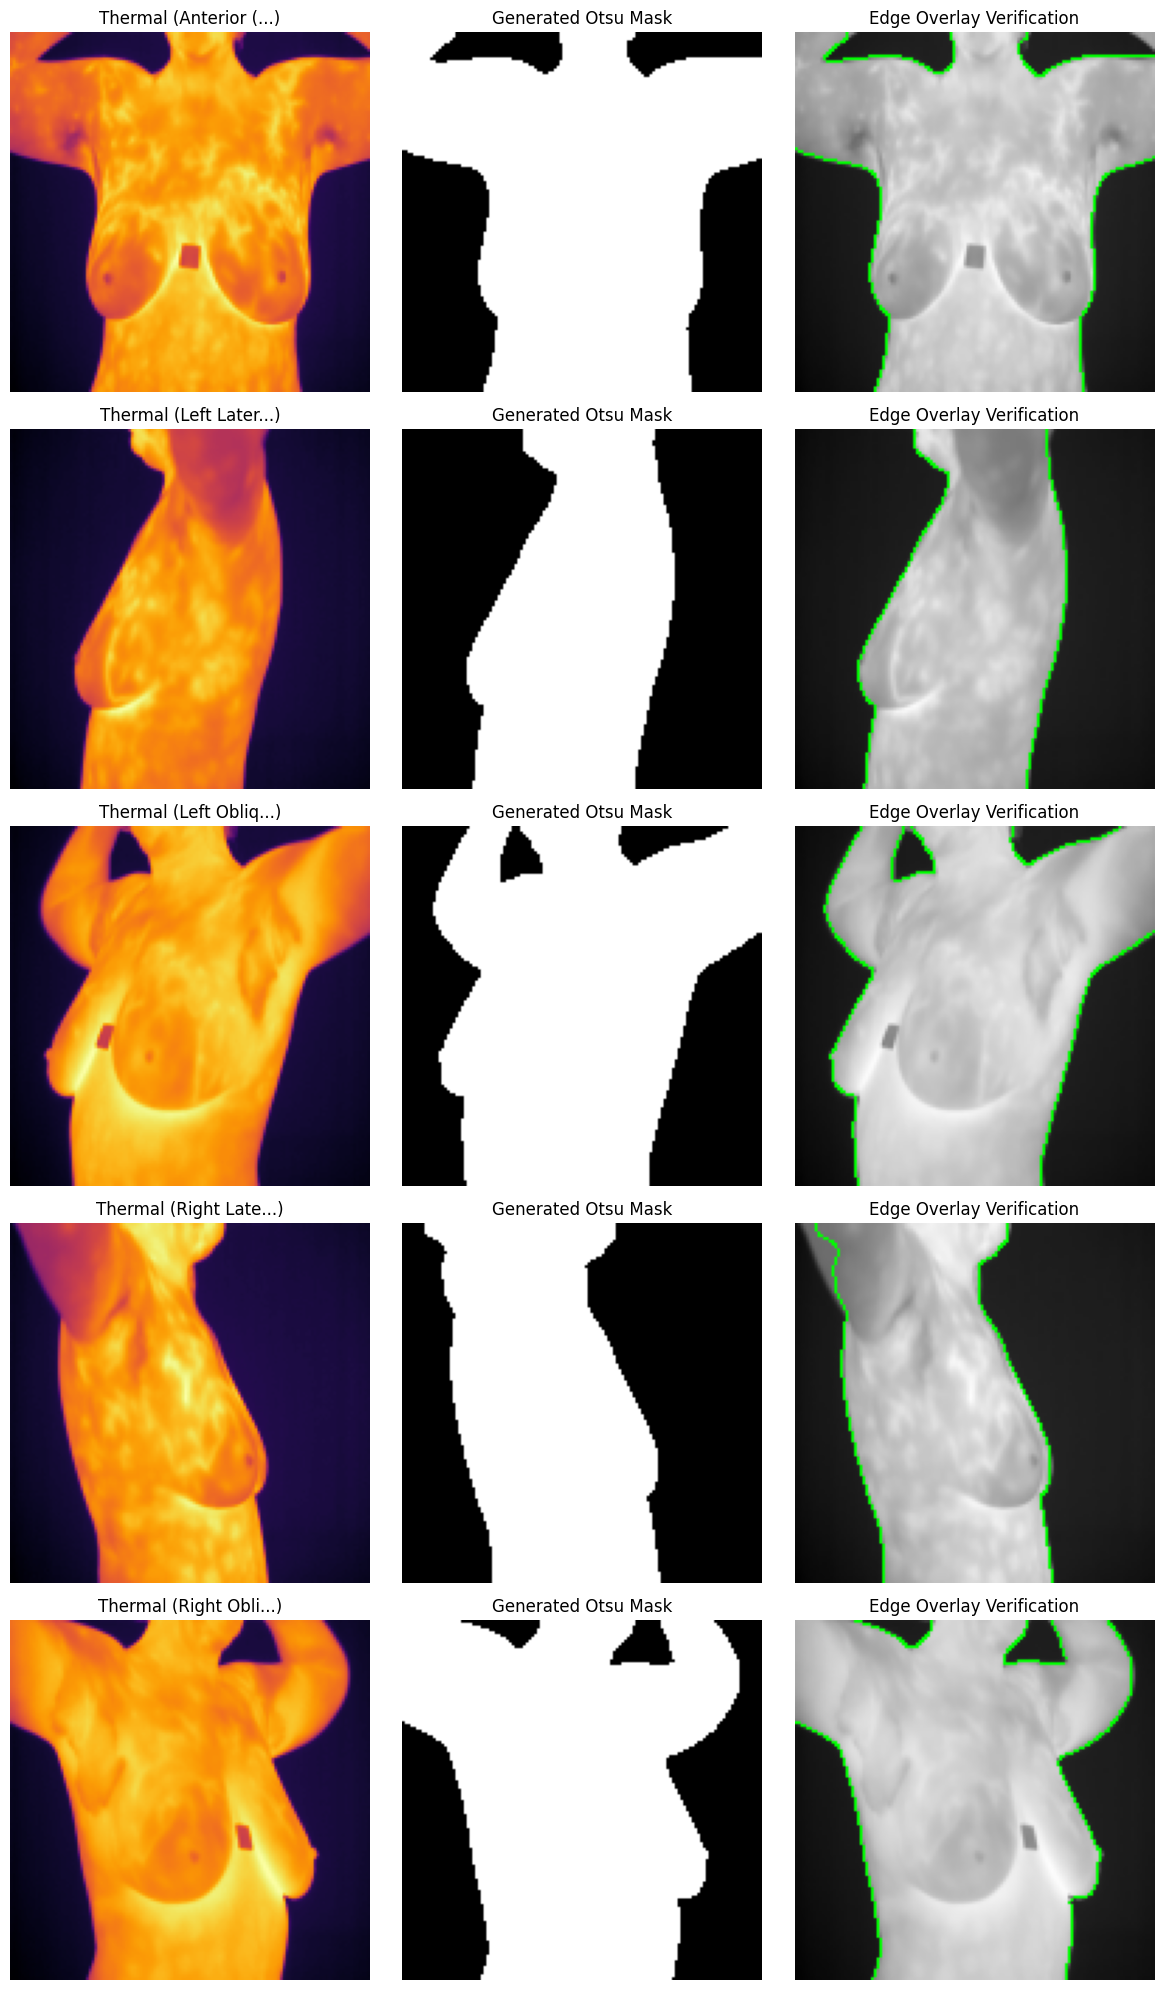

In [15]:
import random
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

def display_random_patient_masks():
    patient_folders = [f for f in os.listdir(OUTPUT_DIR) if f.startswith('Patient_')]
    if not patient_folders:
        print("No processed patients found! Make sure you ran the extraction first.")
        return
        
    patient = random.choice(patient_folders)
    print(f"Visualizing {patient}...")
    
    out_patient_dir = os.path.join(OUTPUT_DIR, patient)
    # Find category subfolder (benign/malignant) if it exists
    subdirs = [d for d in os.listdir(out_patient_dir) if os.path.isdir(os.path.join(out_patient_dir, d))]
    category = subdirs[0] if subdirs else ""
    
    out_subfolder = os.path.join(out_patient_dir, category)
    in_subfolder = os.path.join(DATA_DIR, patient, category)
    
    mask_files = sorted(glob.glob(os.path.join(out_subfolder, "*.png")))
    
    if not mask_files:
        print(f"No masks found for {patient}.")
        return
        
    fig, axes = plt.subplots(len(mask_files), 3, figsize=(12, 4 * len(mask_files)))
    if len(mask_files) == 1:
        axes = axes[np.newaxis, :]
        
    for i, mask_path in enumerate(mask_files):
        view_name = os.path.basename(mask_path).replace('_otsu_mask.png', '')
        
        # Load the generated 128x128 mask
        mask_bytes = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(mask_bytes, cv2.IMREAD_GRAYSCALE)
        
        # Safety check: if the image file is corrupted or 0 bytes
        if mask is None:
            print(f"Warning: Could not read mask file {mask_path}. Skipping.")
            continue
        
        search_prefix = view_name[:10]
        matching_tiffs = [f for f in glob.glob(os.path.join(in_subfolder, "*.tiff")) 
                          if search_prefix in os.path.basename(f)]
        
        if not matching_tiffs:
            print(f"Could not find matching original TIFF for {view_name}")
            continue
            
        tiff_path = matching_tiffs[0]
        
        # Load the original thermal image and resize to match
        img_normalized = load_thermal(tiff_path)
        img_128 = cv2.resize(img_normalized, (128, 128), interpolation=cv2.INTER_AREA)
        
        # Create an overlay to see how well the edges align
        overlay = cv2.cvtColor((img_128 * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        edges = cv2.Canny(mask, 50, 150)
        
        # Safety check: Ensure OpenCV actually returned edge data
        if edges is not None and np.any(edges > 0):
            overlay[edges > 0] = [0, 255, 0] # Highlight edges in bright green
        else:
            print(f"Warning: No edges found for {view_name} (mask is empty or invalid)")
        
        # Plotting
        axes[i, 0].imshow(img_128, cmap='inferno')
        axes[i, 0].set_title(f"Thermal ({search_prefix}...)")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Generated Otsu Mask")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Edge Overlay Verification")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the visualizer
display_random_patient_masks()
